# Mathematical Engineering - Financial Engineering, FY 2025-2026
# Risk Management - Exercise 5: Extended Vasiceck model Monte Carlo simulation for CCR estimation

#### Import the libraries and functions needed created in previous labs

In [92]:
# Importing the libraries
import os
import pickle
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

from utilities.date_functions import (
    business_date_offset,
    date_series,
    year_frac_act_x,
    year_frac_30e_360
)

from utilities.ex0_utilities import (
    bootstrap,
    from_discount_factors_to_zero_rates,
    get_discount_factor_by_zero_rates_linear_interp)

from utilities.ex1_utilities import (
    swap_par_rate,
    SwapType
)

from utilities.ex5_utilities import (
    simulate_ou_process,
    affine_trick,
    update_collateral
)

import warnings
warnings.filterwarnings("ignore")

#### Bootstrap 

In [93]:
# Import here the market data and run your bootstrap function
import datetime as dt

mkt_data_path = "data/"

dates_df = pd.read_csv(mkt_data_path + 'dt.csv', index_col='Market', usecols=['Market','TARGET'], converters={'TARGET':pd.to_datetime})
today = dates_df.loc['Today', 'TARGET']
settlement_date = dates_df.loc['Settlement', 'TARGET']


depo_converter = lambda x: float(x)/100.0
df_depos = pd.read_csv(mkt_data_path + 'depos.csv', index_col='Depos', usecols=['Depos','ASK','BID'], converters={'Depos':pd.to_datetime,'BID':depo_converter,'ASK':depo_converter})
future_converter = lambda x: float(x)
futures = pd.read_csv(mkt_data_path + 'futures.csv', index_col='Futures', usecols=['Futures','ASK','BID'], converters={'Futures':pd.to_datetime,'BID':future_converter,'ASK':future_converter})
expiry = pd.read_csv(mkt_data_path + 'expiry.csv', index_col='Futures', usecols=['Futures', 'Settle', 'Expiry'], converters={'Futures':pd.to_datetime, 'Settle':pd.to_datetime, 'Expiry':pd.to_datetime})
df_futures = futures.join(expiry)
swap_converter = lambda x: float(x)
df_swaps = pd.read_csv(mkt_data_path + 'swaps.csv', index_col='Swaps', usecols=['Swaps','BID','ASK'], converters={'Swaps':pd.to_datetime,'BID':swap_converter,'ASK':swap_converter})

discount_factors, zero_rates = bootstrap(settlement_date, df_depos, df_futures, df_swaps)

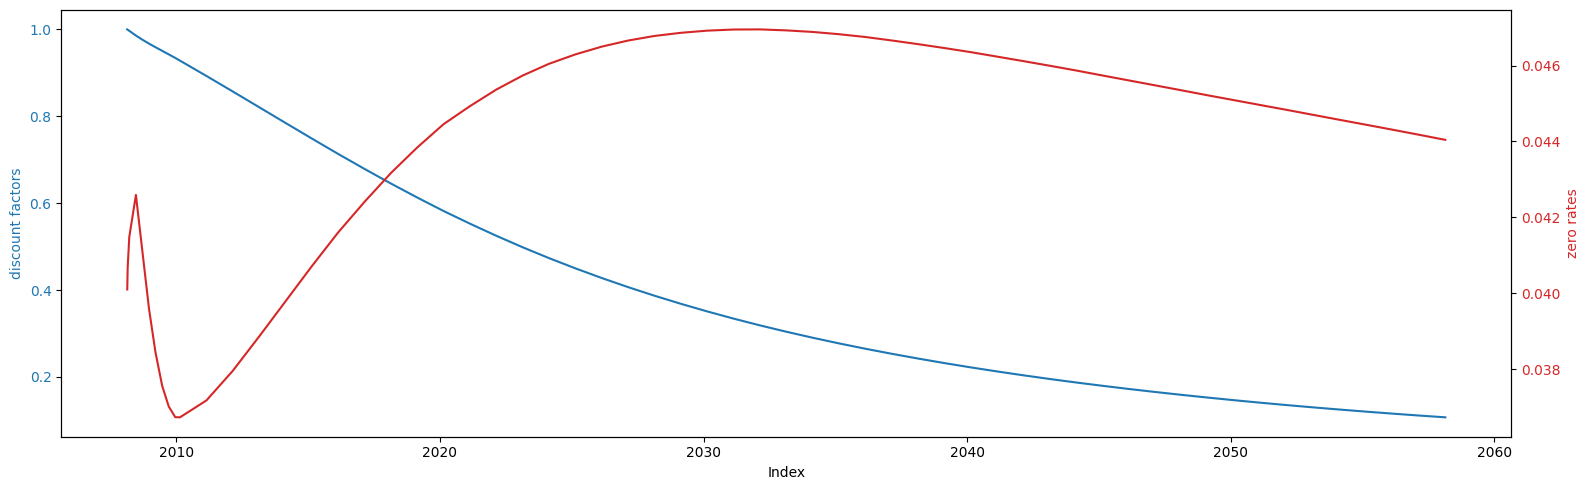

In [94]:
fig, ax1 = plt.subplots(figsize=(16, 5))

ax1.plot(discount_factors.index, discount_factors.values, color='tab:blue')
ax1.set_ylabel('discount factors', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.plot(zero_rates.index, zero_rates.values, color='tab:red')
ax2.set_ylabel('zero rates', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

ax1.set_xlabel('Index')
plt.tight_layout()

plt.show()


#### MonteCarlo grid set up

In [95]:
# Monte Carlo Simulations parameters, grids and outputs to store

# params
simulations_num = 250_000
years_to_simulate = 10

# last point on the simulation grid
simulations_expiry = business_date_offset(settlement_date, year_offset =years_to_simulate)  #fixed from month to year offset

# 40 simulation dates (t_0 non a simulation date)
total_point = 40
point_per_year = total_point//years_to_simulate
simulation_grid = date_series(settlement_date, simulations_expiry, point_per_year)[1:]


# output to compute
expected_positive_exposure = pd.DataFrame(
    data=0.0, index=simulation_grid, columns=["base", "break", "no netting", "netting", "collateral"])

alpha = 0.95
potential_future_exposure = pd.DataFrame(
    data=0.0, index=simulation_grid, columns=["base", "break", "no netting", "netting", "collateral"]
)

#### Set up of the base contract

In [96]:
####### 10 y payer swap #######

# Parameters for the 10y payer swap
notional = 100_000_000
swap_type = SwapType.PAYER
maturity = 10
fixed_freq = 1 # annual

# !!! COMPLETE AS APPROPRIATE !!!
expiry = business_date_offset(base_date= settlement_date , year_offset= maturity) # expiry date
fixed_leg_payment_dates = date_series(t0 = settlement_date , t1= expiry , freq= fixed_freq)

# assume swap traded at par
swap_rate = swap_par_rate(fixed_leg_schedule=fixed_leg_payment_dates, discount_factors=discount_factors, fwd_start_date= settlement_date)

# fixed leg cash flows
tau_fix = [year_frac_30e_360(fixed_leg_payment_dates[k-1], fixed_leg_payment_dates[k])
           for k in range(1, len(fixed_leg_payment_dates))]
irs_cash_flows = pd.Series([swap_rate * t for t in tau_fix],
                           index=fixed_leg_payment_dates[1:])


# fixed leg cash flows extended on simulation grid
# verify that all the payments fall on a t already included in the simulation grid
irs_cash_flows_extended = (
    irs_cash_flows
    .reindex(simulation_grid, fill_value=0.0)
)

#### Set up of the alternative scenarios 

In [97]:
# a) mandatory break clause
# Set up of the break date
break_year = 3
break_month = 6

break_expiry = business_date_offset(base_date= settlement_date , year_offset= break_year, month_offset= break_month) # break date


# b) 5 y payer swap
# Parameters for the 5y receiver swap
# swap 2 has fixed leg quarterly, float leg quarterly (euribor 3m), same yf conventions of base swap
notional_2 = 150_000_000
swap_type_2 = SwapType.RECEIVER
maturity_2 = 5
fixed_freq_2 = 4 

expiry_2 = business_date_offset(base_date= settlement_date , year_offset= maturity_2)
fixed_leg_payment_dates_2 = date_series(t0 = settlement_date , t1= expiry_2 , freq= fixed_freq_2)

# assume swap traded at par
swap_rate_2 = swap_par_rate(fixed_leg_schedule=fixed_leg_payment_dates_2, discount_factors=discount_factors, fwd_start_date= settlement_date)

# fixed leg cash flows (bug fix: multiply by tau_fix_2)
tau_fix_2 = [year_frac_30e_360(fixed_leg_payment_dates_2[k-1], fixed_leg_payment_dates_2[k])
             for k in range(1, len(fixed_leg_payment_dates_2))]
irs_cash_flows_2 = pd.Series(
    data=[swap_rate_2 * t for t in tau_fix_2],
    index=fixed_leg_payment_dates_2[1:])


# fixed leg cash flows extended on simulation grid
irs_cash_flows_extended_2 = (
    irs_cash_flows_2
    .reindex(simulation_grid, fill_value=0.0)
)



# c) CSA agreement
# No IA, no rounding, no haircut, no delay in the posting of the collateral (i.e. margin call done at t -> new collateral posted at t)
# CSA parameters for party B (Polimi Bank)

THR_B = np.inf
MTA_B = 0      # given, choose correctly the other parameters
Cap_B = 0      # given, choose correctly the other parameters

THR_C = 0
MTA_C = 0      # given, choose correctly the other parameters
Cap_C = np.inf

#### x_t OU Process simulations

In [98]:
# OU process parameters

mean_reversion = 0.0205
sigma = 0.0094

In [99]:
np.random.seed(42) # fix seed for reproducibility

x_paths = simulate_ou_process(simulation_grid,
                              settlement_date, 
                              mean_reversion, 
                              sigma, 
                              simulations_num,
                              x0=0)

#### From OU to discount factors and MtM and exposures

In [ ]:
# Inizialization of zero rates
zero_rates = (
    zero_rates.reindex(zero_rates.index.union([simulation_grid[0]]))
    .sort_index()
    .interpolate(method="index")
)

break_date = break_expiry

collateral_posted = np.zeros(simulations_num)
risk_free_rate = np.full(simulations_num, zero_rates.loc[simulation_grid[0]])
last_collateral_posting_date = settlement_date

prev_date = settlement_date

for i, sim_date in enumerate(simulation_grid[0:]):

    dt = year_frac_act_x(prev_date, sim_date, 360)
    x_t = x_paths[:, i]

    A, C = affine_trick(sim_date, simulation_grid, mean_reversion, sigma, discount_factors)
    discount_factors_hw = A.values[None, :] * np.exp(-C.values[None, :] * x_t[:, None])

    future_mask = np.array([T > sim_date for T in simulation_grid])

    fix_pv_per_scen = (
        discount_factors_hw * (irs_cash_flows_extended.values * future_mask)
    ).sum(axis=1)

    idx_TN = simulation_grid.index(fixed_leg_payment_dates[-1])
    float_pv_per_scen = 1.0 - discount_factors_hw[:, idx_TN]

    MtF = notional * (float_pv_per_scen - fix_pv_per_scen)

    # Break clause (6a)    
    # Mandatory break clause: cash-settled at T_br at the MtM of the residual swap.
    # MtM_break(s) = MtM_base(s) for s < T_br, and 0 afterwards.
    if sim_date <= break_date:
        MtF_break = MtF.copy()
    else:
        MtF_break = np.zeros(simulations_num)

    collateral_posted *= np.exp(risk_free_rate * dt)

    if (sim_date - last_collateral_posting_date).days >= 360:
        last_collateral_posting_date = sim_date
        collateral_posted = update_collateral(MtF, collateral_posted, THR_B, THR_C, MTA_B, MTA_C, Cap_B, Cap_C)

    MtF_coll = MtF - collateral_posted

    MtF_pos       = np.where(MtF >= 0,       MtF,       0)
    MtF_pos_break = np.where(MtF_break >= 0, MtF_break, 0)
    MtF_pos_coll  = np.where(MtF_coll >= 0,  MtF_coll,  0)

    expected_positive_exposure.loc[sim_date, "base"]       = np.mean(MtF_pos)
    expected_positive_exposure.loc[sim_date, "break"]      = np.mean(MtF_pos_break)
    expected_positive_exposure.loc[sim_date, "collateral"] = np.mean(MtF_pos_coll)

    potential_future_exposure.loc[sim_date, "base"]       = np.quantile(MtF_pos, alpha)
    potential_future_exposure.loc[sim_date, "break"]      = np.quantile(MtF_pos_break, alpha)
    potential_future_exposure.loc[sim_date, "collateral"] = np.quantile(MtF_pos_coll, alpha)

    # NETTING (6b)
    if sim_date <= expiry_2:
        future_mask_2 = np.array([(T > sim_date) and (T <= expiry_2) for T in simulation_grid])
        fix_pv_per_scen_2 = (discount_factors_hw * (irs_cash_flows_extended_2.values * future_mask_2)).sum(axis=1)
        idx_expiry_2 = simulation_grid.index(fixed_leg_payment_dates_2[-1])
        float_pv_per_scen_2 = 1.0 - discount_factors_hw[:, idx_expiry_2]
        MtF_2 = notional_2 * (fix_pv_per_scen_2 - float_pv_per_scen_2)  # receiver: +fixed -float
    else:
        MtF_2 = np.zeros(simulations_num)

    MtF_portfolio = MtF + MtF_2  # single netting set

    MtF_pos_2         = np.where(MtF_2 >= 0,         MtF_2,         0)
    MtF_pos_portfolio = np.where(MtF_portfolio >= 0,  MtF_portfolio, 0)

    # no netting: aggregated exposure of the two standalone trades = max(M1,0)+max(M2,0)
    MtF_pos_no_netting = MtF_pos + MtF_pos_2

    expected_positive_exposure.loc[sim_date, "no netting"] = np.mean(MtF_pos_no_netting)
    expected_positive_exposure.loc[sim_date, "netting"]    = np.mean(MtF_pos_portfolio)

    # PFE: quantile of the aggregated exposure
    potential_future_exposure.loc[sim_date, "no netting"] = np.quantile(MtF_pos_no_netting, alpha)
    potential_future_exposure.loc[sim_date, "netting"]    = np.quantile(MtF_pos_portfolio, alpha)
    if i < len(simulation_grid) - 1:
                next_date = simulation_grid[i + 1]
                tau_next = year_frac_act_x(sim_date, next_date, 360)
                df_next = discount_factors_hw[:, i + 1]
                risk_free_rate = -np.log(df_next) / tau_next

    prev_date = sim_date

#### Peak PFE

In [101]:
# Compute for each scenario the peak-PFE and the t at which it materialize
peak_pfe = pd.DataFrame(data = 0, index=["base", "break", "no netting", "netting", "collateral"], columns = ['t','Peak_PFE'])

peak_pfe['Peak_PFE'] = potential_future_exposure.max(axis=0)
peak_pfe['t'] = potential_future_exposure.idxmax(axis=0)

In [102]:
peak_pfe

,t,Peak_PFE
base,2012-02-20,1.663654e+07
break,2011-02-21,1.616687e+07
no netting,2012-02-20,1.663654e+07
netting,2013-02-19,1.615023e+07
collateral,2008-11-19,6.232333e+06


#### PLOT 

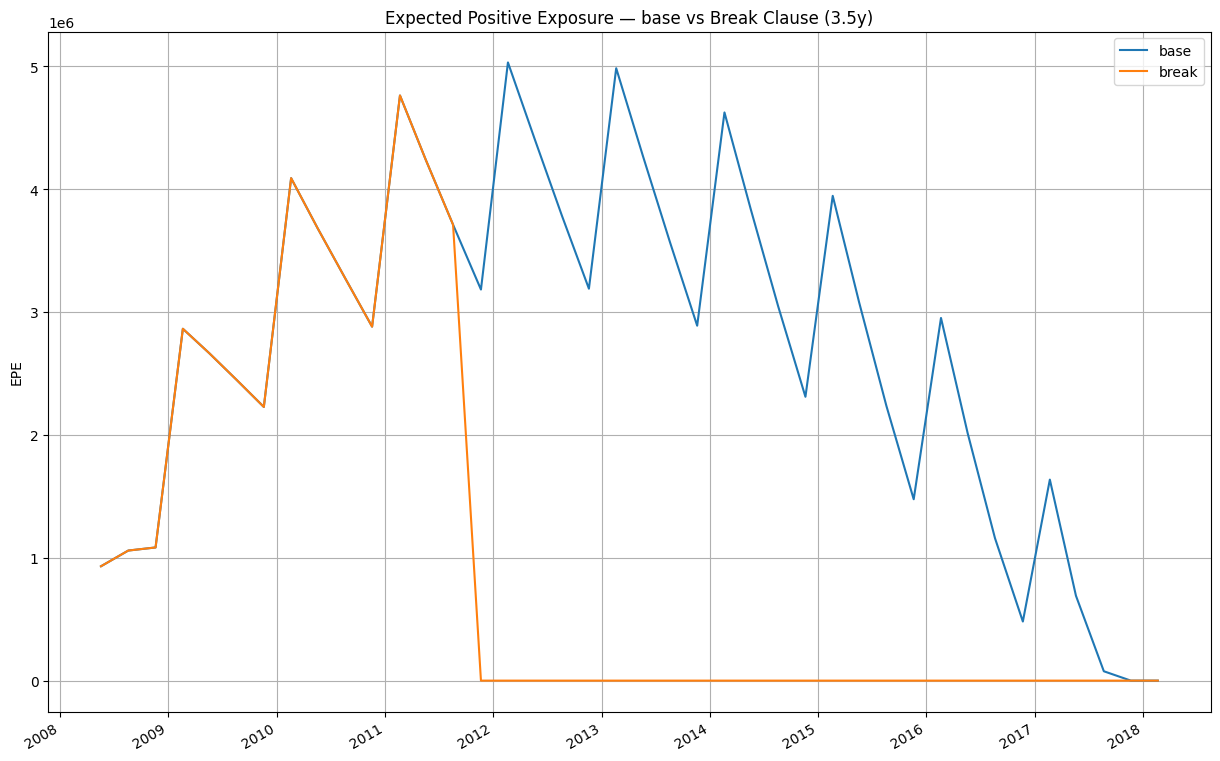

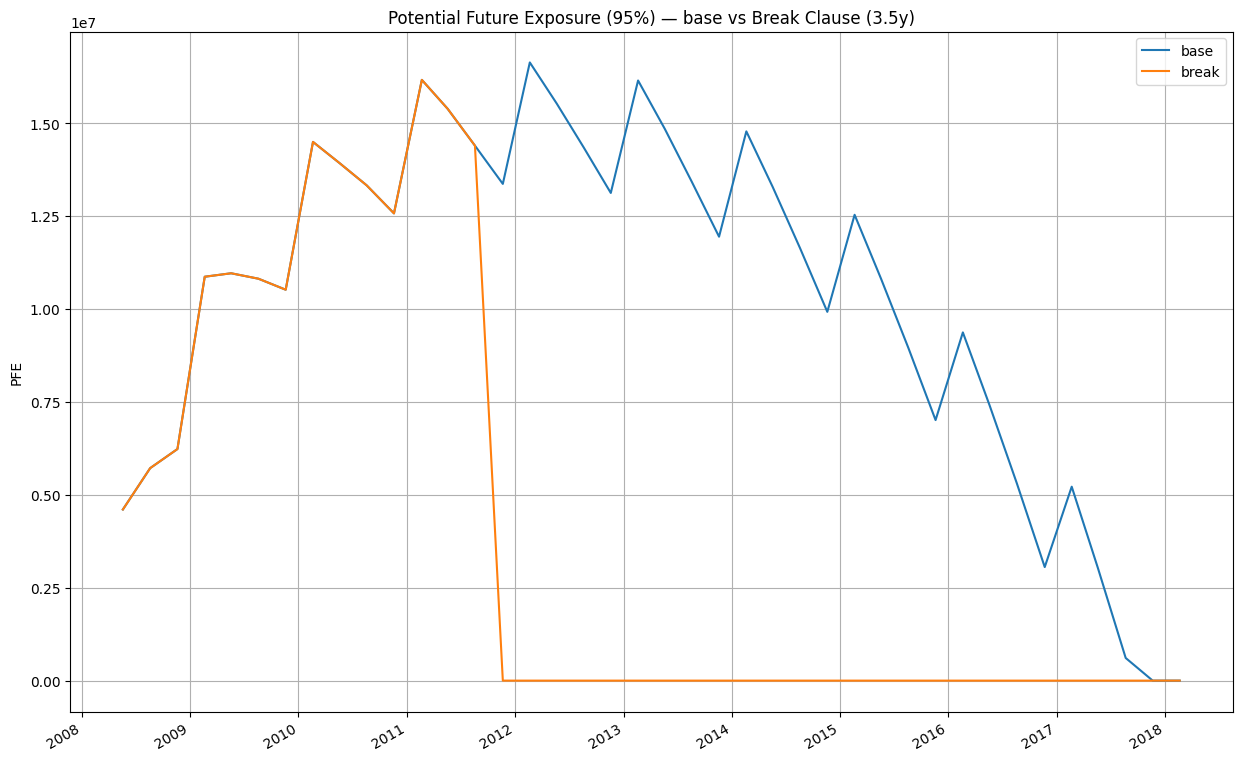

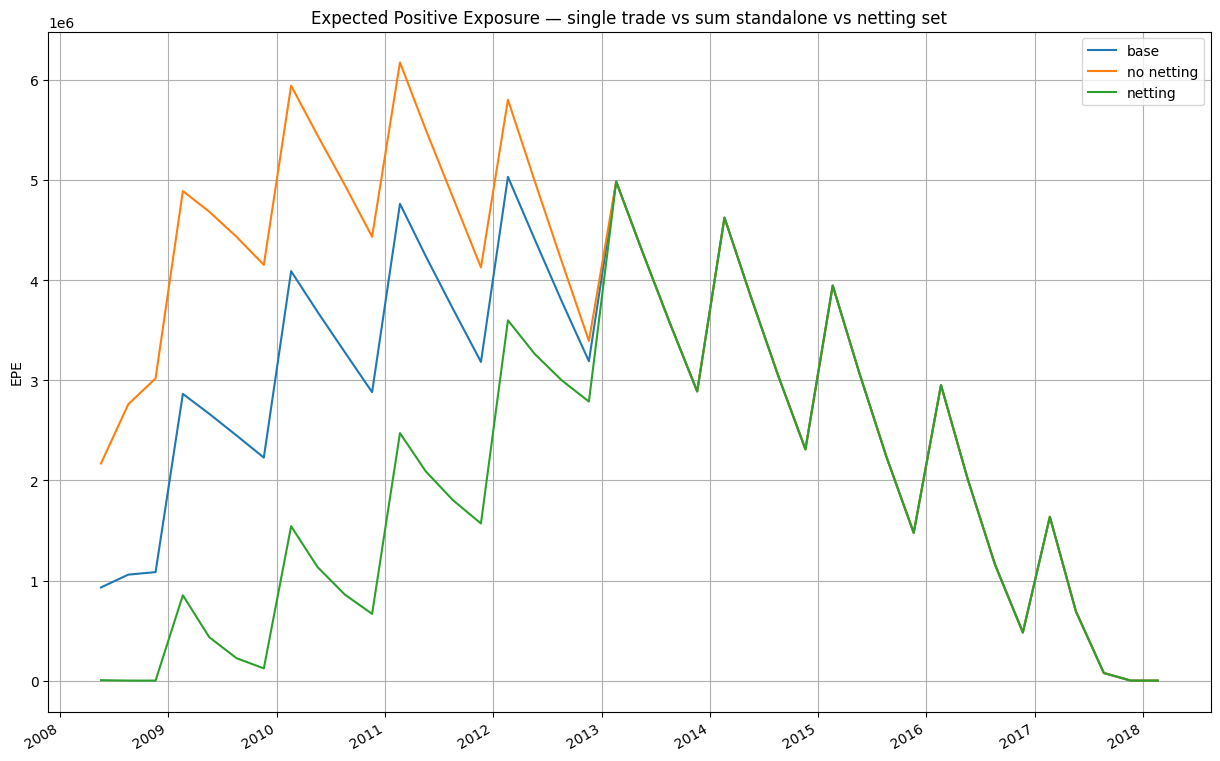

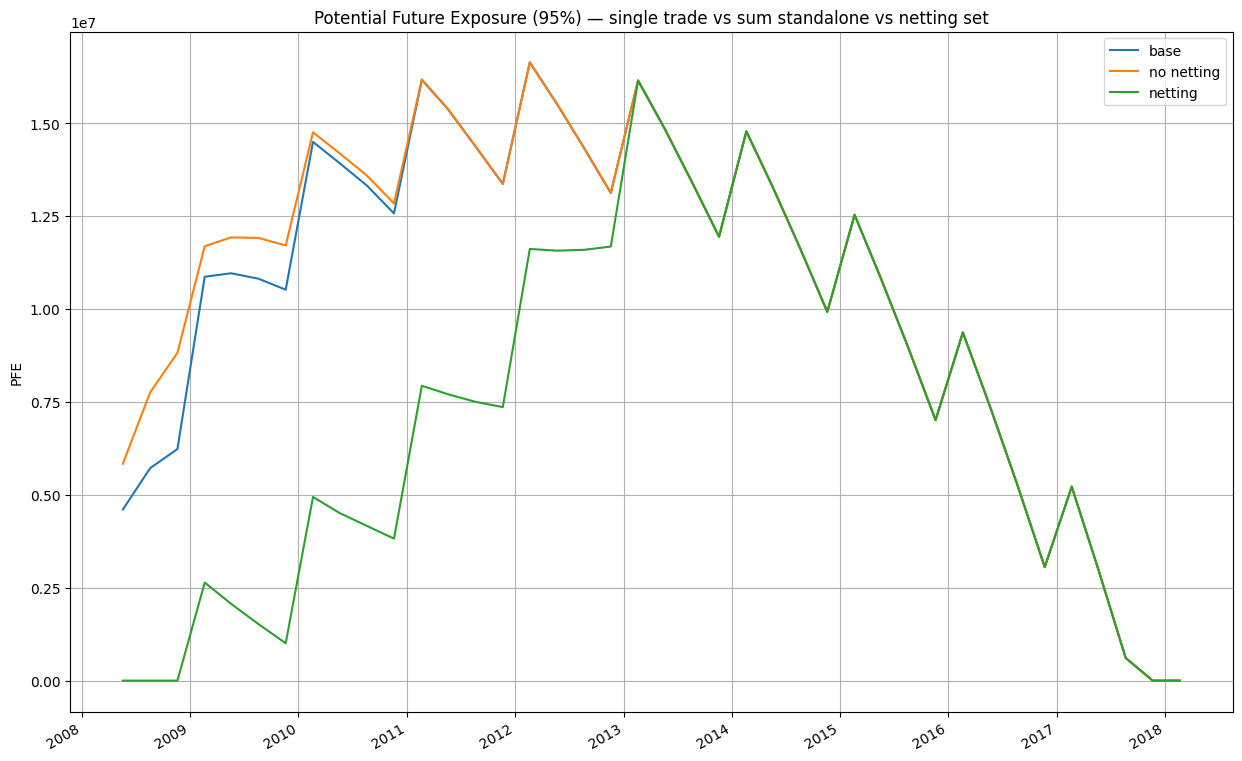

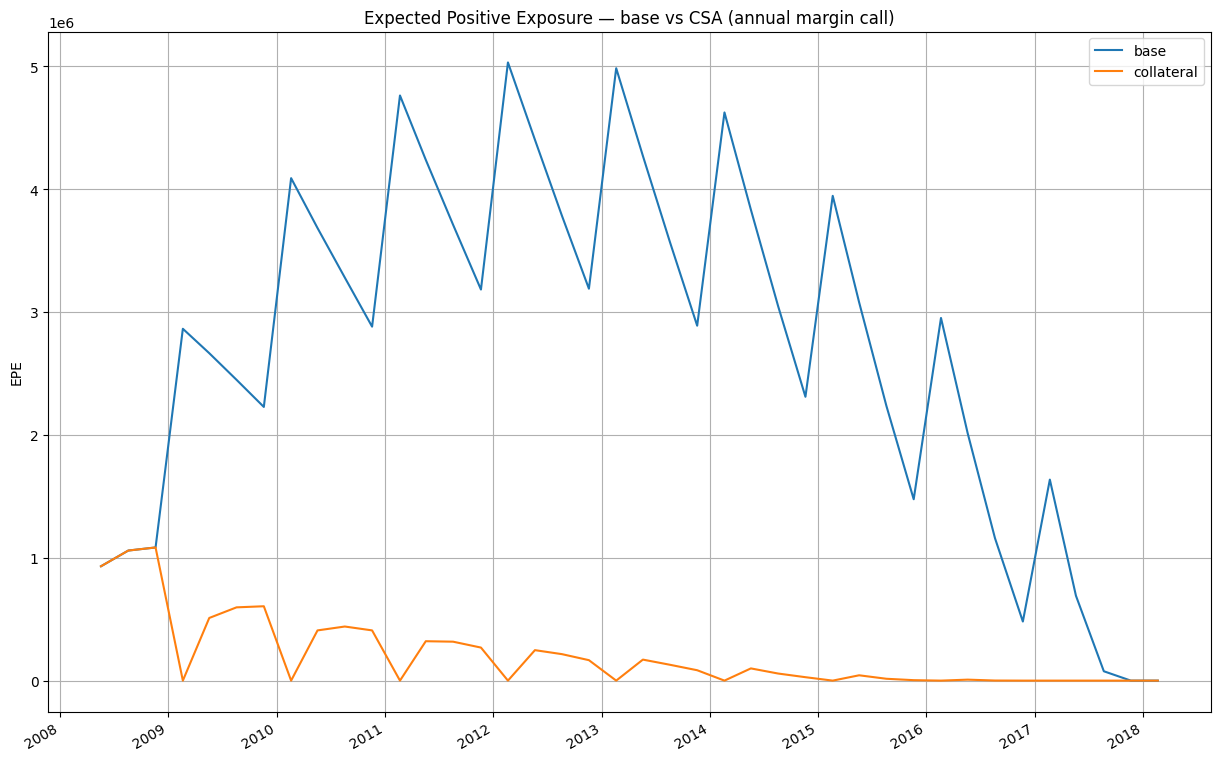

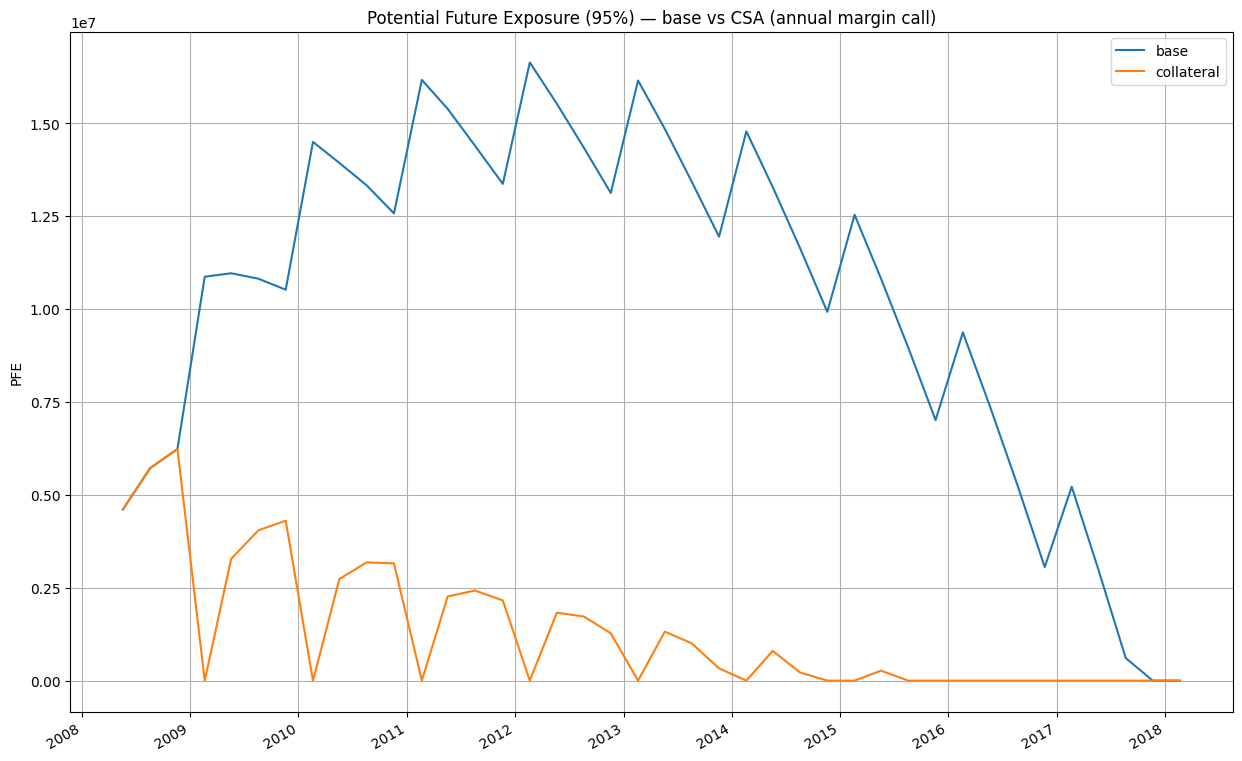

In [103]:
# plot 6 a — Break clause vs base
expected_positive_exposure[['base', 'break']].plot(figsize=(15, 10))
plt.title("Expected Positive Exposure — base vs Break Clause (3.5y)")
plt.ylabel("EPE")
plt.grid()
plt.show()

potential_future_exposure[['base', 'break']].plot(figsize=(15, 10))
plt.title("Potential Future Exposure (95%) — base vs Break Clause (3.5y)")
plt.ylabel("PFE")
plt.grid()
plt.show()

# plot 6 b — Netting: single trade (base) vs sum of standalone vs full netting set
expected_positive_exposure[['base', 'no netting', 'netting']].plot(figsize=(15, 10))
plt.title("Expected Positive Exposure — single trade vs sum standalone vs netting set")
plt.ylabel("EPE")
plt.grid()
plt.show()

potential_future_exposure[['base', 'no netting', 'netting']].plot(figsize=(15, 10))
plt.title("Potential Future Exposure (95%) — single trade vs sum standalone vs netting set")
plt.ylabel("PFE")
plt.grid()
plt.show()

# plot 6 c — CSA: base vs collateralised
expected_positive_exposure[['base', 'collateral']].plot(figsize=(15, 10))
plt.title("Expected Positive Exposure — base vs CSA (annual margin call)")
plt.ylabel("EPE")
plt.grid()
plt.show()

potential_future_exposure[['base', 'collateral']].plot(figsize=(15, 10))
plt.title("Potential Future Exposure (95%) — base vs CSA (annual margin call)")
plt.ylabel("PFE")
plt.grid()
plt.show()

#### CVA estimations

In [ ]:
# Parameters
hazard_rate = 0.02
lgd = 0.6
# 7a) CVA for all scenarios
# CVA_0 ≈ LGD * Σ_i B(0, t_i) * EPE(t_i) * [S(t_{i-1}) - S(t_i)]

# Discount factors at simulation dates
B0 = np.array([
    get_discount_factor_by_zero_rates_linear_interp(
        discount_factors.index[0], d, discount_factors.index, discount_factors.values)
    for d in simulation_grid
])

# Year fractions from settlement
tau = np.array([year_frac_act_x(settlement_date, d, 360) for d in simulation_grid])

# Survival probabilities S(0, t_i) = exp(-lambda * t_i)
survival_prob = np.exp(-hazard_rate * tau)

# Incremental default probabilities: ΔPD(t_i) = S(0, t_{i-1}) - S(0, t_i)
survival_prev = np.concatenate([[1.0], survival_prob[:-1]])
delta_PD = survival_prev - survival_prob

# CVA for each scenario
cva_results = {}
for scenario in expected_positive_exposure.columns:
    epe = expected_positive_exposure[scenario].values
    cva_results[scenario] = lgd * np.sum(epe * B0 * delta_PD)

cva_df = pd.DataFrame.from_dict(cva_results, orient='index', columns=['CVA'])
print(cva_df)

# 7b) CVA sensitivities for the base scenario
base_cva = cva_results["base"]
base_epe = expected_positive_exposure["base"].values
bump = 0.0001  # 1bp

# Sensitivity 1: interest rate parallel shift (+/- 1bp), discounting-only approximation
# This captures ONLY the effect of the bump on the CVA discount factors B(0,t).
B0_up   = B0 * np.exp(-bump * tau)
B0_down = B0 * np.exp( bump * tau)

cva_rate_up   = lgd * np.sum(base_epe * B0_up   * delta_PD)
cva_rate_down = lgd * np.sum(base_epe * B0_down * delta_PD)
dCVA_drate_per_bp = (cva_rate_up - cva_rate_down) / 2   # 1bp finite difference

# --- Sensitivity 2: hazard rate lambda (+/- 1bp) ---
def cva_with_lambda(lam):
    surv = np.exp(-lam * tau)
    surv_prev = np.concatenate([[1.0], surv[:-1]])
    dPD = surv_prev - surv
    return lgd * np.sum(base_epe * B0 * dPD)

dCVA_dlambda_per_bp = (cva_with_lambda(hazard_rate + bump) - cva_with_lambda(hazard_rate - bump)) / 2

# Sensitivity 3: LGD (+/- 1pp)
# CVA is linear in LGD: dCVA/dLGD = CVA / LGD
dCVA_dLGD_per_pp = (base_cva / lgd) * 0.01   # impact of +1pp change in LGD

print(f"\nBase CVA:                       {base_cva:>15,.2f}")
print(f"ΔCVA per +1bp parallel rate:    {dCVA_drate_per_bp:>15,.2f}   (discount-only — see note)")
print(f"ΔCVA per +1bp hazard rate:      {dCVA_dlambda_per_bp:>15,.2f}")
print(f"ΔCVA per +1pp LGD:              {dCVA_dLGD_per_pp:>15,.2f}")

                      CVA
base        254248.628133
break       107063.741296
no netting  325828.433317
netting     166166.656258
collateral   22252.544243

Base CVA:                            254,248.63
ΔCVA per +1bp parallel rate:            -110.01   (discount-only — see note)
ΔCVA per +1bp hazard rate:             1,164.46
ΔCVA per +1pp LGD:                     4,237.48


In [ ]:
# 7b — full rate sensitivity via re-bootstrap + re-MC
# The "discount-only" sensitivity computed in the previous cell misses the dominant effect:
# a parallel shift in rates moves the MtM of the swap (and therefore the EPE) as well as
# the CVA discount factors. Here we re-bootstrap the curve with +/- 1 bp shifts and re-run
# the MC pricing of the base-case 10y payer IRS, then form a centred finite difference.

bump_rate = 0.0001  # 1 bp

def cva_base_at_shock(shock: float) -> float:
    """Re-bootstrap with a parallel shift and recompute the base-case CVA."""
    # 1) shocked curve
    df_sh, _ = bootstrap(settlement_date, df_depos, df_futures, df_swaps, shock=shock)

    # 2) the contract is already in place — K is the ORIGINAL par rate, not re-priced.
    #    So the cash-flows series stays unchanged.
    cf_extended = irs_cash_flows_extended.values

    # 3) the OU state process does not depend on the curve, so we reuse x_paths
    #    (variance reduction: same random numbers across the two shock legs)
    epe_sh = np.zeros(len(simulation_grid))
    idx_TN_local = simulation_grid.index(fixed_leg_payment_dates[-1])

    for i, sim_date in enumerate(simulation_grid):
        x_t = x_paths[:, i]
        A_sh, C_sh = affine_trick(sim_date, simulation_grid,
                                  mean_reversion, sigma, df_sh)
        B_sT = A_sh.values[None, :] * np.exp(-C_sh.values[None, :] * x_t[:, None])

        fut_mask = np.array([T > sim_date for T in simulation_grid])
        fix_pv   = (B_sT * (cf_extended * fut_mask)).sum(axis=1)
        float_pv = 1.0 - B_sT[:, idx_TN_local]
        MtF_sh   = notional * (float_pv - fix_pv)

        epe_sh[i] = np.mean(np.maximum(MtF_sh, 0.0))

    # 4) CVA on the shocked curve
    B0_sh = np.array([
        get_discount_factor_by_zero_rates_linear_interp(
            df_sh.index[0], d, df_sh.index, df_sh.values
        ) for d in simulation_grid
    ])
    return lgd * np.sum(epe_sh * B0_sh * delta_PD)


cva_up   = cva_base_at_shock(+bump_rate)
cva_down = cva_base_at_shock(-bump_rate)
dCVA_drate_full_per_bp = (cva_up - cva_down) / 2   # centred 1-bp finite difference

print("Full rate sensitivity — re-bootstrap + re-MC, base case 10y payer IRS")
print("-" * 72)
print(f"  CVA at +1 bp shift:                {cva_up:>15,.2f}")
print(f"  CVA at -1 bp shift:                {cva_down:>15,.2f}")
print(f"  ΔCVA per +1 bp parallel shift:     {dCVA_drate_full_per_bp:>15,.2f}")
print()
print(f"  Discount-only approximation:       {dCVA_drate_per_bp:>15,.2f}")
print(f"  Effect of the EPE channel:         {dCVA_drate_full_per_bp - dCVA_drate_per_bp:>+15,.2f}")

Full rate sensitivity — re-bootstrap + re-MC, base case 10y payer IRS
------------------------------------------------------------------------
  CVA at +1 bp shift:                     256,080.68
  CVA at -1 bp shift:                     252,427.13
  ΔCVA per +1 bp parallel shift:            1,826.77

  Discount-only approximation:               -110.01
  Effect of the EPE channel:               +1,936.78
